# 02 — Feature Engineering

Linguistic feature extraction from the WildChat longitudinal cohort.

**Input:**
- `data/interim/wildchat_longitudinal.parquet` — original 1.7 GB parquet (conversation + turn text)
- `data/interim/conv_metadata.parquet` — small metadata table with session numbers (from notebook 01)

**Output:** `data/processed/feature_matrix.parquet` — one row per (user, conversation/session) with all linguistic features.

**Science check (required before proceeding to notebook 03):**
- Inspect feature distributions for skew, zero-inflation, and outliers
- Note which features are sparse/limited by the data (flagged in cell 5)
- Confirm early/late feature averages look plausible before modelling

In [1]:
import random
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from tqdm.notebook import tqdm

sys.path.insert(0, '..')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PARQUET_PATH  = '../data/interim/wildchat_longitudinal.parquet'
META_PATH     = '../data/interim/conv_metadata.parquet'
BATCH_SIZE    = 500

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Conversation Metadata (Small — Already Session-Numbered)

In [2]:
conv_meta = pd.read_parquet(META_PATH)
conv_meta['conversation_id'] = conv_meta['conversation_id'].astype(str)

# Index for O(1) lookups during the extraction loop
conv_meta_idx = conv_meta.set_index('conversation_id')
valid_conv_ids = set(conv_meta_idx.index)

print(f'Metadata loaded: {len(conv_meta):,} conversations, {conv_meta["hashed_ip"].nunique():,} users')
conv_meta.head()

Metadata loaded: 505,397 conversations, 12,577 users


,conversation_id,hashed_ip,timestamp,redacted,n_turns,n_user_turns,session_number,return_interval_hours,log_n_user_turns,log_return_interval_hours
0,1038434,000035130d2300660bcd63747bd977570960a80e46f8bc...,2023-06-27 09:34:53+00:00,False,8,4,1,NaN,1.609438,0.000000
1,1038556,000035130d2300660bcd63747bd977570960a80e46f8bc...,2023-06-27 09:39:47+00:00,False,2,1,2,0.081667,0.693147,0.078503
2,1038629,000035130d2300660bcd63747bd977570960a80e46f8bc...,2023-06-27 09:47:48+00:00,False,4,2,3,0.133611,1.098612,0.125408
3,1038921,000035130d2300660bcd63747bd977570960a80e46f8bc...,2023-06-27 10:12:00+00:00,False,4,2,4,0.403333,1.098612,0.338850
4,1038941,000035130d2300660bcd63747bd977570960a80e46f8bc...,2023-06-27 10:13:59+00:00,False,2,1,5,0.033056,0.693147,0.032521


## 2. Feature Extraction

Features are extracted by `src/extract_features.py` (run separately — ~4 min for 505k conversations).
The optimised script uses a single-pass token scan per conversation and `orjson` for fast JSON parsing.
This cell loads the pre-computed result.

In [3]:
feature_matrix = pd.read_parquet('../data/processed/feature_matrix.parquet')
print(f'Feature matrix: {feature_matrix.shape[0]:,} rows × {feature_matrix.shape[1]} columns')
feature_matrix.head()

Feature matrix: 505,397 rows × 17 columns


,hashed_ip,conversation_id,session_number,n_user_turns,return_interval_hours,log_n_user_turns,log_return_interval_hours,fpp_rate,self_disclosure_rate,hedging_rate,filler_rate,gratitude_rate,refusal_resistance_rate,question_to_statement_ratio,mean_message_length,type_token_ratio,sentiment_slope
0,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101001,1,1,NaN,0.693147,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.090909,232.0,0.637931,0.0
1,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...,101007,1,1,NaN,0.693147,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,44.0,0.568182,0.0
2,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101008,2,1,0.065556,0.693147,0.063496,0.0,0.0,0.0,0.004167,0.0,0.0,0.090909,240.0,0.641667,0.0
3,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101012,3,1,0.031111,0.693147,0.030637,0.0,0.0,0.0,0.003802,0.0,0.0,0.088235,263.0,0.627376,0.0
4,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101017,4,1,0.039167,0.693147,0.038419,0.0,0.0,0.0,0.003497,0.0,0.0,0.083333,286.0,0.608392,0.0


## 3. Science Check — Feature Usability Flags

In [4]:
FEATURE_COLS = [
    'fpp_rate', 'self_disclosure_rate', 'hedging_rate', 'filler_rate',
    'refusal_resistance_rate', 'gratitude_rate', 'question_to_statement_ratio',
    'mean_message_length', 'session_duration_minutes', 'type_token_ratio',
    'sentiment_slope', 'n_user_turns',
    'log_n_user_turns', 'return_interval_hours', 'log_return_interval_hours',
]

print('=== Feature usability check ===\n')
for col in FEATURE_COLS:
    if col not in feature_matrix.columns:
        print(f'  MISSING : {col}')
        continue
    zero_pct = (feature_matrix[col] == 0).mean()
    null_pct = feature_matrix[col].isna().mean()
    flag = ''
    if col == 'session_duration_minutes':
        flag = '  ⚠ EXCLUDE — all turns share one timestamp; always 0'
    elif zero_pct > 0.90:
        flag = f'  ⚠ SPARSE — {zero_pct:.0%} zeros (secondary feature)'
    print(f'  {col:<35}  zero={zero_pct:.1%}  null={null_pct:.1%}{flag}')

# Drop session_duration_minutes — no per-turn timestamps in this dataset
feature_matrix = feature_matrix.drop(columns=['session_duration_minutes'], errors='ignore')
print('\nsession_duration_minutes dropped (always 0 — no per-turn timestamps in parquet)')

=== Feature usability check ===

  fpp_rate                             zero=89.5%  null=0.0%
  self_disclosure_rate                 zero=98.2%  null=0.0%  ⚠ SPARSE — 98% zeros (secondary feature)
  hedging_rate                         zero=89.6%  null=0.0%
  filler_rate                          zero=81.4%  null=0.0%
  refusal_resistance_rate              zero=98.1%  null=0.0%  ⚠ SPARSE — 98% zeros (secondary feature)
  gratitude_rate                       zero=83.1%  null=0.0%
  question_to_statement_ratio          zero=72.5%  null=0.0%
  mean_message_length                  zero=0.0%  null=0.0%
  MISSING : session_duration_minutes
  type_token_ratio                     zero=0.2%  null=0.0%
  sentiment_slope                      zero=96.5%  null=0.0%  ⚠ SPARSE — 96% zeros (secondary feature)
  n_user_turns                         zero=0.0%  null=0.0%
  log_n_user_turns                     zero=0.0%  null=0.0%
  return_interval_hours                zero=0.2%  null=2.5%
  log_return_int

In [5]:
## 4. Feature Distributions

plot_cols = [c for c in feature_matrix.columns
             if c not in ('hashed_ip', 'conversation_id', 'session_number')]

n_cols = 4
n_rows = -(-len(plot_cols) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

for ax, col in zip(axes.flat, plot_cols):
    feature_matrix[col].dropna().hist(bins=50, ax=ax, color='#2E6FA8', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('')

for ax in axes.flat[len(plot_cols):]:
    ax.set_visible(False)

plt.suptitle('Feature distributions — all sessions (one row per conversation)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

feature_matrix[plot_cols].describe().round(4)

In [6]:
## 5. Early vs Late Session Feature Means (Sanity Check)

                             early (1–3)  late (10+)      delta  pct_change
fpp_rate                        0.001027    0.001926   0.000899        87.5
self_disclosure_rate            0.000039    0.000082   0.000042       107.1
hedging_rate                    0.000594    0.001064   0.000469        79.0
filler_rate                     0.001375    0.002601   0.001226        89.2
refusal_resistance_rate         0.025598    0.018351  -0.007246       -28.3
gratitude_rate                  0.001428    0.001282  -0.000146       -10.2
question_to_statement_ratio     0.080789    0.081155   0.000366         0.5
mean_message_length           172.642337  231.659767  59.017429        34.2
type_token_ratio                0.755570    0.746421  -0.009149        -1.2
sentiment_slope                -0.001911   -0.003553  -0.001642       -85.9


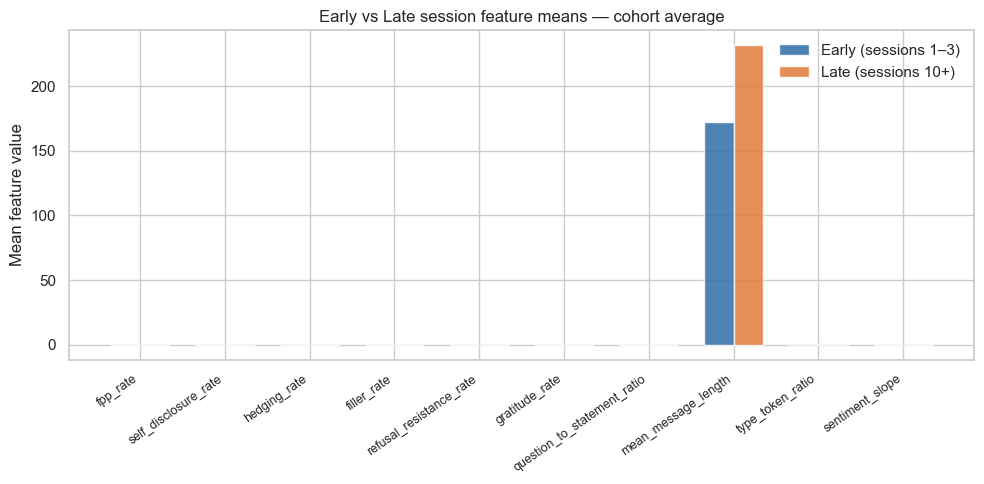

In [7]:
ling_cols = [
    'fpp_rate', 'self_disclosure_rate', 'hedging_rate', 'filler_rate',
    'refusal_resistance_rate', 'gratitude_rate', 'question_to_statement_ratio',
    'mean_message_length', 'type_token_ratio', 'sentiment_slope',
]

early = feature_matrix[feature_matrix['session_number'] <= 3][ling_cols].mean()
late  = feature_matrix[feature_matrix['session_number'] >= 10][ling_cols].mean()

comparison = pd.DataFrame({'early (1–3)': early, 'late (10+)': late})
comparison['delta'] = comparison['late (10+)'] - comparison['early (1–3)']
comparison['pct_change'] = (comparison['delta'] / comparison['early (1–3)'].abs().replace(0, np.nan) * 100).round(1)
print(comparison.round(6).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ling_cols))
w = 0.35
ax.bar(x - w/2, early.values, w, label='Early (sessions 1–3)', color='#2E6FA8', alpha=0.85)
ax.bar(x + w/2, late.values,  w, label='Late (sessions 10+)',  color='#E07B39', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ling_cols, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean feature value')
ax.set_title('Early vs Late session feature means — cohort average')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('../outputs/figures/02_early_vs_late_means.png', dpi=150)
plt.show()

## 6. Save Feature Matrix

In [8]:
out_path = '../data/processed/feature_matrix.parquet'
feature_matrix.to_parquet(out_path, index=False)
print(f'Saved {len(feature_matrix):,} rows × {feature_matrix.shape[1]} columns to {out_path}')
print('Columns:', list(feature_matrix.columns))

Saved 505,397 rows × 17 columns to ../data/processed/feature_matrix.parquet
Columns: ['hashed_ip', 'conversation_id', 'session_number', 'n_user_turns', 'return_interval_hours', 'log_n_user_turns', 'log_return_interval_hours', 'fpp_rate', 'self_disclosure_rate', 'hedging_rate', 'filler_rate', 'gratitude_rate', 'refusal_resistance_rate', 'question_to_statement_ratio', 'mean_message_length', 'type_token_ratio', 'sentiment_slope']
